# Exploring the CBIS-DDSM Dataset

###### In this notebook, we explore the CBIS-DDSM dataset, a curated mammography database widely used for computer-aided detection (CADe) and computer-aided diagnosis (CADx) research.

###### We will learn:
###### - How the dataset is organized
###### - What information is available in the metadata
###### - How mammography images are stored
###### - How to visualize mammograms, regions of interest (ROIs), and segmentation masks

### Understanding the metadata files

#### Importing libraries

###### The following libraries are used to load and visualize the clinical metadata and mammographic images contained in the CBIS-DDSM dataset.

In [1]:
import pandas as pd                    # Data manipulation and analysis
import numpy as np                     # Numerical operations
import os                              # File and folder navigation
import pydicom                         # Reading DICOM medical images
import matplotlib.pyplot as plt        # Image visualization

#### Understanding the information contained

###### CBIS-DDSM provides metadata in CSV (Comma-Separated Values) files: text file used to store tabular data

###### For calcification and masses cases, the file contains information such as:

--------------------------------------------------------------------------------------------------------------------------------
##### - Patient id: unique identifier assigned to each case in the dataset. 
--------------------------------------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------------------------------------
##### - Breast density: it describes the proportion of fibroglandular tissue

###### 1 Almost entirely fatty: the breast is mostly fat, making abnormalities easier to detect.
###### 2 Scattered fibroglandular densities: some dense tissue is present, but most of the breast is fatty.
###### 3 Heterogeneously dense: large areas of dense tissue may obscure small lesions.
###### 4 Extremely dense: the breast is very dense, making lesion detection more difficult.
--------------------------------------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------------------------------------
##### - Left or right breast
--------------------------------------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------------------------------------
##### - Image views

###### CC (Craniocaudal): top-to-bottom view of the breast.
###### MLO (Mediolateral Oblique): angled side view including upper breast tissue.
--------------------------------------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------------------------------------
##### - Abnormality id: it identifies individual lesions within the same case 

###### 1 First abnormality.
###### 2 Second abnormality.
###### 3 Third abnormality.
###### 4 Fourth abnormality.
--------------------------------------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------------------------------------
##### - Abnormality type

###### Calcification: small calcium deposits within the breast tissue.
###### Mass: localized area of abnormal tissue within the breast.
--------------------------------------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------------------------------------
##### - Calcification type 

###### PUNCTATE: small, round calcifications.                            
###### AMORPHOUS: indistinct calcifications without a clear shape.                           
###### PLEOMORPHIC: calcifications with varying shapes and sizes.                         
###### FINE LINEAR BRANCHING: thin branching calcifications.
###### ROUND AND REGULAR: uniform round calcifications.
###### COARSE: large calcifications.
###### LUCENT CENTER: calcifications with a dark center.
###### EGGSHELL: thin rim-like calcifications.
###### VASCULAR: calcifications within blood vessels.
###### SKIN: calcifications located in the skin.
--------------------------------------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------------------------------------
##### - Mass shape

###### ROUND: circular-shaped lesion.
###### OVAL: oval-shaped lesion.
###### LOBULATED: lesion with smooth rounded lobes.
###### IRREGULAR: lesion with an uneven shape; often more suspicious.
###### ARCHITECTURAL DISTORTION: distortion of normal breast tissue without a clear mass.
###### FOCAL ASYMMETRIC DENSITY: localized area of increased breast density.
###### ASYMMETRIC BREAST TISSUE: unequal breast tissue appearance between breasts.
###### LYMPH NODE: visible lymph node within the breast.
###### N/A: shape information not available.
--------------------------------------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------------------------------------
##### - Calcification distribution: it describes how calcifications are spatially arranged  

###### CLUSTERED: calcifications grouped in a small area.
###### SEGMENTAL: distributed along a breast duct segment.
###### LINEAR: arranged in a line, following a duct.
###### REGIONAL: spread over a large breast region.
###### DIFFUSELY SCATTERED: randomly distributed throughout the breast.
###### CLUSTERED-LINEAR: clustered with a linear arrangement.
###### LINEAR-SEGMENTAL: linear distribution within a duct segment.
###### N/A: not available or not applicable.
--------------------------------------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------------------------------------
##### - Mass margins: it describes the appearance of the lesion boundary 

###### CIRCUMSCRIBED: well-defined and clearly visible border.
###### OBSCURED: border partly hidden by surrounding tissue.
###### ILL DEFINED: poorly defined or indistinct border.
###### MICROLOBULATED: small lobulations along the margin.
###### SPICULATED: spiky radiating margin; highly suspicious.
###### N/A: not available or not applicable.
--------------------------------------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------------------------------------
##### - Assessment (BI-RADS) -Breast Imaging Reporting and Data System-:

###### 0 Incomplete: more imaging or prior exams are needed before a final assessment can be made.
###### 1 Negative: no abnormal findings; breast appears normal.
###### 2 Benign finding: a non-cancerous finding is present.
###### 3 Probably benign: very low probability of cancer.
###### 4 Suspicious abnormality: cancer is possible.
###### 5 Highly suggestive of malignancy: very high probability of cancer.
--------------------------------------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------------------------------------
##### - Pathology: represents the ground-truth diagnosis

###### BENIGN: the lesion was investigated and confirmed to be non-cancerous. 
###### BENIGN WITHOUT CALLBACK: the finding was considered benign during screening and did not require additional evaluation.
###### MALIGNANT: the lesion was confirmed as breast cancer.
--------------------------------------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------------------------------------
##### - Subtlety: it measures how visible or conspicuous an abnormality is on an image ##

###### 1 Extremely subtle; very difficult to detect.
###### 2 Subtle; difficult to identify without careful inspection.
###### 3 Moderately visible; detectable but not obvious.
###### 4 Relatively obvious.
###### 5 Very obvious; highly conspicuous abnormality.
--------------------------------------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------------------------------------
##### - Image paths ## 

###### image file path: it's the path to the full mammography image.
###### cropped image file path: it's the path to the cropped image centered on the annotated abnormality.
###### ROI mask file path: it's the path to the binary Region of Interest (ROI) mask marking the abnormality location.
--------------------------------------------------------------------------------------------------------------------------------

###### Not all variables are available for every case. Calcification-related attributes are not present in mass cases, and mass-related attributes are not present in calcification cases.

#### Loading the *calc_case_description_train_set.csv* file

###### By exploring this CSV file, we can understand how the dataset is structured, the information available for each case, and how these data can be used for visualization and analysis.

In [17]:
ruta_csv = r"Downloads\calc_case_description_train_set.csv" # ruta_csv = stores the location of the metadata file on the computer.

df = pd.read_csv(ruta_csv) # pd.read_csv(ruta_csv) = reads the CSV file and converts it into a pandas DataFrame, 
                           # a table-like structure that allows us to explore, filter, analyze, and visualize the data.
                           # df = variable that stores the DataFrame for later use.

In [18]:
# Display the first rows of the DataFrame to obtain an initial overview of the dataset.
df.head()

# It allows us to quickly inspect the dataset structure, identify the available columns, 
# and verify that the data were loaded correctly.

,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.959...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_MLO/1.3.6.1.4.1.95...,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00007,4,LEFT,MLO,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_MLO/1.3.6.1.4.1.959...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00008,1,LEFT,CC,1,calcification,NaN,REGIONAL,2,BENIGN_WITHOUT_CALLBACK,3,Calc-Training_P_00008_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...


#### Exploring an individual patient

###### To understand how the metadata is organized and linked to the corresponding images, a representative patient is selected from the dataset. Examining a single case allows us to explore the available clinical information, mammographic views, and lesion annotations before visualizing the associated DICOM images.

In [19]:
patient_id = "P_00030"                        # patient_id stores the identifier of the patient of interest
caso = df[df["patient_id"] == patient_id]     # df["patient_id"] == patient_id creates a condition that selects only the rows belonging to that patient
                                              # df["patient_id"] filters the DataFrame using that condition
                                              # caso stores the resulting subset of data
caso
# Displaying 'caso' shows all abnormalities and associated information available for the selected patient

,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
42,P_00030,2,LEFT,CC,1,calcification,COARSE,NaN,2,BENIGN_WITHOUT_CALLBACK,5,Calc-Training_P_00030_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00030_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00030_LEFT_CC_1/1.3.6.1.4.1.95...
43,P_00030,2,LEFT,CC,2,calcification,VASCULAR,NaN,2,BENIGN_WITHOUT_CALLBACK,5,Calc-Training_P_00030_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00030_LEFT_CC_2/1.3.6.1.4.1.95...,Calc-Training_P_00030_LEFT_CC_2/1.3.6.1.4.1.95...
44,P_00030,2,LEFT,MLO,1,calcification,COARSE,NaN,2,BENIGN_WITHOUT_CALLBACK,5,Calc-Training_P_00030_LEFT_MLO/1.3.6.1.4.1.959...,Calc-Training_P_00030_LEFT_MLO_1/1.3.6.1.4.1.9...,Calc-Training_P_00030_LEFT_MLO_1/1.3.6.1.4.1.9...
45,P_00030,2,LEFT,MLO,2,calcification,VASCULAR,NaN,2,BENIGN_WITHOUT_CALLBACK,5,Calc-Training_P_00030_LEFT_MLO/1.3.6.1.4.1.959...,Calc-Training_P_00030_LEFT_MLO_2/1.3.6.1.4.1.9...,Calc-Training_P_00030_LEFT_MLO_2/1.3.6.1.4.1.9...
46,P_00030,2,RIGHT,CC,1,calcification,VASCULAR,NaN,2,BENIGN_WITHOUT_CALLBACK,4,Calc-Training_P_00030_RIGHT_CC/1.3.6.1.4.1.959...,Calc-Training_P_00030_RIGHT_CC_1/1.3.6.1.4.1.9...,Calc-Training_P_00030_RIGHT_CC_1/1.3.6.1.4.1.9...
47,P_00030,2,RIGHT,MLO,1,calcification,VASCULAR,NaN,2,BENIGN_WITHOUT_CALLBACK,4,Calc-Training_P_00030_RIGHT_MLO/1.3.6.1.4.1.95...,Calc-Training_P_00030_RIGHT_MLO_1/1.3.6.1.4.1....,Calc-Training_P_00030_RIGHT_MLO_1/1.3.6.1.4.1....


#### Full mammographic images

###### Viewing the full mammograms allows us to understand the overall breast anatomy. Each mammographic study includes four standard views: CC (Cranio-Caudal) and MLO (Medio-Lateral Oblique) projections of both breasts. These complementary views help identify and localize abnormalities from different viewing angles. 

###### Before focusing on individual lesions and their annotations, we first visualize the complete mammographic images available for the selected patient.

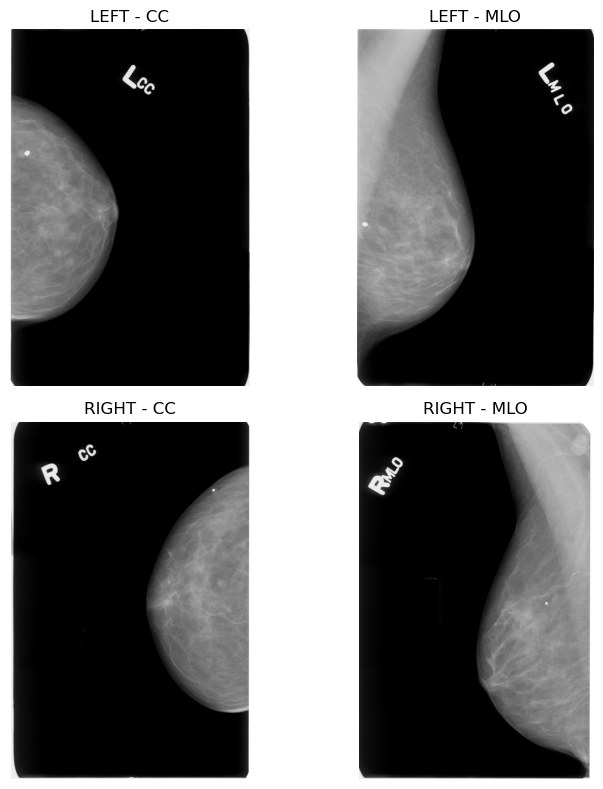

In [20]:
# Create a 2 × 2 grid for displaying the mammograms
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

# Load and display the LEFT-CC mammogram
ds = pydicom.dcmread(r"G:\TASC\cbis_ddsm\Calc-Training_P_00030_LEFT_CC\40023\03429\3ee0d0e8-132b-4685-b58b-65955e08347f.dcm")
axes[0,0].imshow(ds.pixel_array, cmap="gray")
axes[0,0].set_title("LEFT - CC")
axes[0,0].axis("off")

# Load and display the LEFT-MLO mammogram
ds = pydicom.dcmread(r"G:\TASC\cbis_ddsm\Calc-Training_P_00030_LEFT_MLO\95489\76403\398b2aab-a605-45c5-a0bf-bc47ef8a3f0e.dcm")
axes[0,1].imshow(ds.pixel_array, cmap="gray")
axes[0,1].set_title("LEFT - MLO")
axes[0,1].axis("off")

# Load and display the RIGHT-CC mammogram
ds = pydicom.dcmread(r"G:\TASC\cbis_ddsm\Calc-Training_P_00030_RIGHT_CC\34303\34342\466f26ef-c6bc-4e23-a481-bc9378c21929.dcm")
axes[1,0].imshow(ds.pixel_array, cmap="gray")
axes[1,0].set_title("RIGHT - CC")
axes[1,0].axis("off")

# Load and display the RIGHT-MLO mammogram
ds = pydicom.dcmread(r"G:\TASC\cbis_ddsm\Calc-Training_P_00030_RIGHT_MLO\21014\91077\e685f7bd-5e53-413d-9020-4f2db31894e7.dcm")
axes[1,1].imshow(ds.pixel_array, cmap="gray")
axes[1,1].set_title("RIGHT - MLO")
axes[1,1].axis("off")


plt.tight_layout()  # Adjust spacing between images
plt.show()          # Display the figure

#### Cropped regions of interest (ROIs)

###### After visualizing the complete mammograms, we focus on the cropped Regions of Interest (ROIs) provided in the dataset. These images correspond to the areas containing the annotated calcifications and allow a closer examination of the lesions.

###### For each calcification, the ROI is available in both CC and MLO views, providing complementary perspectives of the same abnormality.

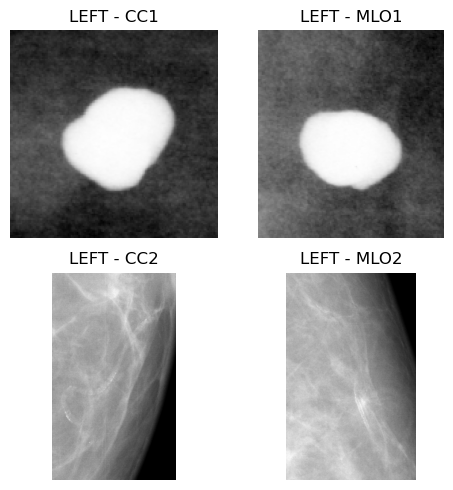

In [6]:
# Create a 2 × 2 grid for displaying the ROIs corresponding to the annotated calcifications
fig, axes = plt.subplots(2, 2, figsize=(5, 5))

# Load and display Calcification 1 in the CC view
ds = pydicom.dcmread(r"G:\TASC\cbis_ddsm\Calc-Training_P_00030_LEFT_CC_1\01222\32034\1151d293-7f92-4eca-8834-afd8595d0260.dcm")
axes[0,0].imshow(ds.pixel_array, cmap="gray")
axes[0,0].set_title("LEFT - CC1")
axes[0,0].axis("off")

# Load and display Calcification 1 in the MLO view
ds = pydicom.dcmread(r"G:\TASC\cbis_ddsm\Calc-Training_P_00030_LEFT_MLO_1\71515\71360\e37b735d-108a-4fa0-859f-e22ff3a2bc25.dcm")
axes[0,1].imshow(ds.pixel_array, cmap="gray")
axes[0,1].set_title("LEFT - MLO1")
axes[0,1].axis("off")

# Load and display Calcification 2 in the CC view
ds = pydicom.dcmread(r"G:\TASC\cbis_ddsm\Calc-Training_P_00030_LEFT_CC_2\76088\10410\f7d968b5-52ad-4a1d-80dc-1bc3dc8a7c68.dcm")
axes[1,0].imshow(ds.pixel_array, cmap="gray")
axes[1,0].set_title("LEFT - CC2")
axes[1,0].axis("off")

# Load and display Calcification 2 in the MLO view
ds = pydicom.dcmread(r"G:\TASC\cbis_ddsm\Calc-Training_P_00030_LEFT_MLO_2\65705\96215\20935d83-bd33-4982-8c76-4c6444d0dfce.dcm")
axes[1,1].imshow(ds.pixel_array, cmap="gray")
axes[1,1].set_title("LEFT - MLO2")
axes[1,1].axis("off")

plt.tight_layout()  # Adjust spacing between images
plt.show()          # Display the figure

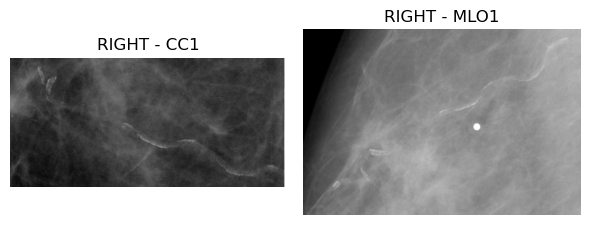

In [7]:
# Create a 1 × 2 grid for displaying the ROIs corresponding to the annotated calcifications
fig, axes = plt.subplots(1, 2, figsize=(6, 6))

# Load and display Calcification 1 in the CC view
ds = pydicom.dcmread(r"G:\TASC\cbis_ddsm\Calc-Training_P_00030_RIGHT_CC_1\53513\10058\68a50a43-abf5-4d51-961c-055b1c8dd38c.dcm")
axes[0].imshow(ds.pixel_array, cmap="gray")
axes[0].set_title("RIGHT - CC1")
axes[0].axis("off")

# Load and display Calcification 1 in the MLO view
ds = pydicom.dcmread(r"G:\TASC\cbis_ddsm\Calc-Training_P_00030_RIGHT_MLO_1\47128\90297\5b9ad504-41d4-4e5e-bdc7-5c981c490391.dcm")
axes[1].imshow(ds.pixel_array, cmap="gray")
axes[1].set_title("RIGHT - MLO1")
axes[1].axis("off")

plt.tight_layout()  # Adjust spacing between images
plt.show()          # Display the figure

###### The ROIs provide a magnified view of the annotated lesions, making the calcifications easier to identify than  in the full mammograms. The same abnormality can be observed from both CC and MLO projections, allowing its appearance to be examined from different viewing angles.

#### Binary segmentation masks

###### After visualizing the full mammograms and focusing on the regions of interest (ROI) where the microcalcifications are located, we now present the corresponding binary masks.

###### These masks provide a pixel-level representation of the segmented lesions, where foreground pixels indicate calcification regions and background pixels represent non-lesion tissue. The left breast contains two distinct  calcification regions across the CC and MLO views, while the right breast contains a single region.

###### This representation allows a clearer isolation of the lesions, removing anatomical context and retaining only the segmented structures for further analysis.

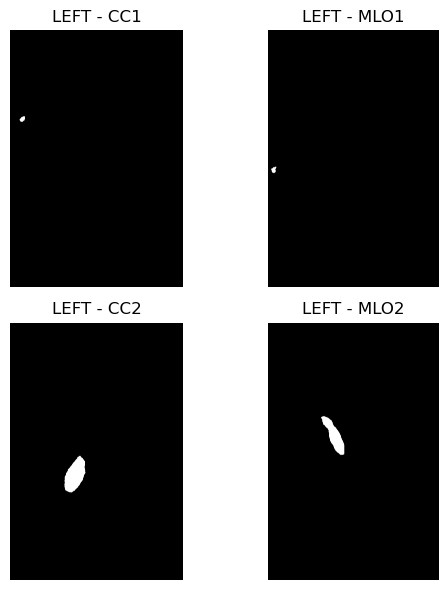

In [8]:
# Create a 2 × 2 grid to display binary segmentation masks
fig, axes = plt.subplots(2, 2, figsize=(6, 6))

# Load and display the binary mask corresponding to Calcification 1 (CC view)
ds = pydicom.dcmread(r"G:\TASC\cbis_ddsm\Calc-Training_P_00030_LEFT_CC_1\01222\32034\f872eb06-2347-4c80-8737-6d9ce89058ba.dcm")
axes[0,0].imshow(ds.pixel_array, cmap="gray")
axes[0,0].set_title("LEFT - CC1")
axes[0,0].axis("off")

# Load and display the binary mask corresponding to Calcification 1 (MLO view)
ds = pydicom.dcmread(r"G:\TASC\cbis_ddsm\Calc-Training_P_00030_LEFT_MLO_1\71515\71360\3ef1eeff-6e52-4a55-aed8-19bdf6578f2b.dcm")
axes[0,1].imshow(ds.pixel_array, cmap="gray")
axes[0,1].set_title("LEFT - MLO1")
axes[0,1].axis("off")

# Load and display the binary mask corresponding to Calcification 2 (CC view)
ds = pydicom.dcmread(r"G:\TASC\cbis_ddsm\Calc-Training_P_00030_LEFT_CC_2\76088\10410\3cf6eed0-ed3d-4903-b1c4-5f1329cb1471.dcm")
axes[1,0].imshow(ds.pixel_array, cmap="gray")
axes[1,0].set_title("LEFT - CC2")
axes[1,0].axis("off")

# Load and display the binary mask corresponding to Calcification 2 (MLO view)
ds = pydicom.dcmread(r"G:\TASC\cbis_ddsm\Calc-Training_P_00030_LEFT_MLO_2\65705\96215\57aef835-b0ef-41c5-95fd-7e8f63c887ec.dcm")
axes[1,1].imshow(ds.pixel_array, cmap="gray")
axes[1,1].set_title("LEFT - MLO2")
axes[1,1].axis("off")

plt.tight_layout()  # Adjust spacing between images
plt.show()          # Display the figure

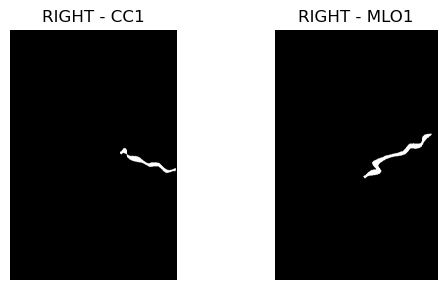

In [9]:
# Create a 2 × 2 grid to display binary segmentation masks
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

# Load and display the binary mask corresponding to Calcification 1 (CC view)
ds = pydicom.dcmread(r"G:\TASC\cbis_ddsm\Calc-Training_P_00030_RIGHT_CC_1\53513\10058\8cde9fb9-6c77-4163-a2b7-0fc95c1074e8.dcm")
axes[0].imshow(ds.pixel_array, cmap="gray")
axes[0].set_title("RIGHT - CC1")
axes[0].axis("off")

# Load and display the binary mask corresponding to Calcification 1 (MLO view)
ds = pydicom.dcmread(r"G:\TASC\cbis_ddsm\Calc-Training_P_00030_RIGHT_MLO_1\47128\90297\8e72b75c-a044-45f8-801b-12b1375b9856.dcm")
axes[1].imshow(ds.pixel_array, cmap="gray")
axes[1].set_title("RIGHT - MLO1")
axes[1].axis("off")

plt.tight_layout()  # Adjust spacing between images
plt.show()          # Display the figure

###### In the left breast, two distinct calcification clusters are visible, each appearing as small, localized high-intensity regions. These masks are relatively compact and well-defined, indicating separated lesions.

###### Overall, the masks successfully isolate the lesions from the surrounding tissue, enabling a clear pixel-wise representation of the calcifications.

### Exploring other patient cases

In [10]:
# Enter the patient ID to explore
patient_id = "P_00020"

# Retrieve all records associated with the selected patient
patient_data = df[df["patient_id"] == patient_id][[
    "patient_id",
    "breast density",
    "left or right breast",
    "image view",
    "abnormality id",
    "abnormality type",
    "calc type",
    "calc distribution",
    "assessment",
    "pathology",
    "subtlety"
]]

# Display the metadata
patient_data

,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety
33,P_00020,2,LEFT,CC,1,calcification,PLEOMORPHIC,CLUSTERED,4,MALIGNANT,4
34,P_00020,2,LEFT,MLO,1,calcification,PLEOMORPHIC,CLUSTERED,4,MALIGNANT,4
